# Loan Default — Exploratory Data Analysis (EDA) & PD Model

**Dataset:** 148,670 rows × 34 columns
**Target variable (`Status`):** 1 = Default, 0 = No Default

## Sections
1. Import Libraries
2. Load & Inspect Data
3. Data Cleaning & Missing Value Analysis
4. Univariate Analysis
5. Bivariate Analysis (vs Target)
6. Correlation Analysis
7. Outlier Detection
8. Key Insights Summary
9. Feature Engineering & Encoding
10. Probability of Default (PD) Modeling


This model is designed as an Application Probability of Default (PD) Model, where the objective is to estimate the likelihood of borrower default using only information available at the time of loan application. Variables generated during underwriting or loan pricing were excluded to ensure the model reflects a realistic lending decision process.

**Assumptions**
1) The prediction is made before loan approval.

2) Only application-stage information is used.

3) Post-underwriting and pricing variables are excluded.

4) The model predicts the probability of borrower default, not loan approv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from sklearn.impute import KNNImputer

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
print('Libraries imported successfully')

Libraries imported successfully


In [2]:
df=pd.read_csv('Loan_Default.csv')
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
print(f'Shape:{df.shape[0]:,} rows x{df.shape[1]} columns')

Shape:148,670 rows x34 columns


In [4]:
##Data Type
print (df.dtypes)
print(f'\nNumerical columns: {df.select_dtypes(include=np.number).shape[1]}')
print(f'\nObject columns: {df.select_dtypes(include="object").shape[1]}')

ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

In [5]:
#Numerical summary
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [6]:
#Categorical summary
df.describe(include='object')

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,...,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
count,145326,148670,147762,148670,148536,148670,148670,148670,148549,148670,...,148670,148670,148670,148670,148670,148670,148470,148470,148670,148670
unique,2,4,2,3,4,2,2,2,2,2,...,2,3,2,4,4,2,7,2,4,2
top,cf,Male,nopre,type1,p3,l1,nopc,nob/c,not_neg,not_int,...,sb,pr,home,1U,CIB,CIB,45-54,to_inst,North,direct
freq,135348,42346,124621,113173,55934,142344,148114,127908,133420,141560,...,148637,138201,148637,146480,48152,74392,34720,95814,74722,148637


## Step 3 — Data Cleaning & Missing Value Analysis


In [7]:
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
missing_df = pd.DataFrame({"Missing Count" :missing, "Missing%": missing_pct}).sort_values("Missing Count", ascending = False)
missing_df = missing_df[missing_df["Missing Count" ]>0]

print(f'Columns with missing values {len(missing_df)}/{df.shape[1]}')
missing_df

Columns with missing values 14/34


,Missing Count,Missing%
Upfront_charges,39642,26.66
Interest_rate_spread,36639,24.64
rate_of_interest,36439,24.51
dtir1,24121,16.22
LTV,15098,10.16
property_value,15098,10.16
income,9150,6.15
loan_limit,3344,2.25
approv_in_adv,908,0.61
submission_of_application,200,0.13


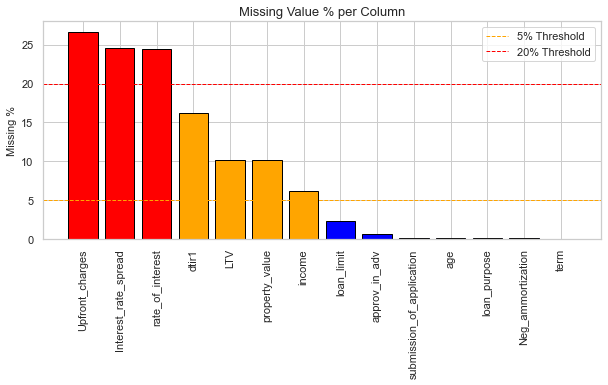

In [8]:
plt.figure(figsize = (10,4))
color = [
    "red" if x > 20
    else "orange" if x > 5
    else "blue"
    for x in missing_df["Missing%"]
]
bars = plt.bar(missing_df.index, missing_df["Missing%"],color=color, edgecolor ='black')
plt.axhline(5, color="orange", linestyle="--", linewidth=1, label='5% Threshold')
plt.axhline(20, color="red", linestyle="--", linewidth=1, label='20% Threshold')
plt.title("Missing Value % per Column")
plt.ylabel("Missing %")
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [9]:
#Duplicate check
dup = df.duplicated().sum()
print('Duplicate rows:',dup)

Duplicate rows: 0


In [10]:
#Drop Id
df=df.drop(columns=["ID"])

In [11]:
#Seperate Column types
target = 'Status'
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Numerical features({len(num_cols )}):{num_cols}')
print(f'Categorical features({len(cat_cols)}):{cat_cols}')

Numerical features(12):['year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'Status', 'dtir1']
Categorical features(21):['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']


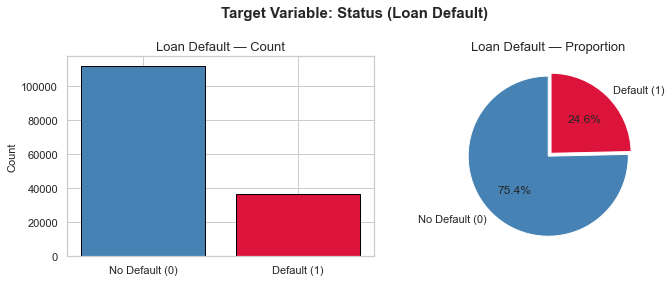

In [12]:
#Target variable distribution
counts= df[target].value_counts().sort_index()
labels = ['No Default (0)','Default (1)']
fig,axes= plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, counts.values, color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Loan Default — Count')
axes[0].set_ylabel('Count')
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'crimson'], startangle=90, explode=[0, 0.05])
axes[1].set_title('Loan Default — Proportion')
plt.suptitle('Target Variable: Status (Loan Default)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
num_feats = [c for c in num_cols if c!="Status"]

In [14]:
num_feats

['year',
 'loan_amount',
 'rate_of_interest',
 'Interest_rate_spread',
 'Upfront_charges',
 'term',
 'property_value',
 'income',
 'Credit_Score',
 'LTV',
 'dtir1']

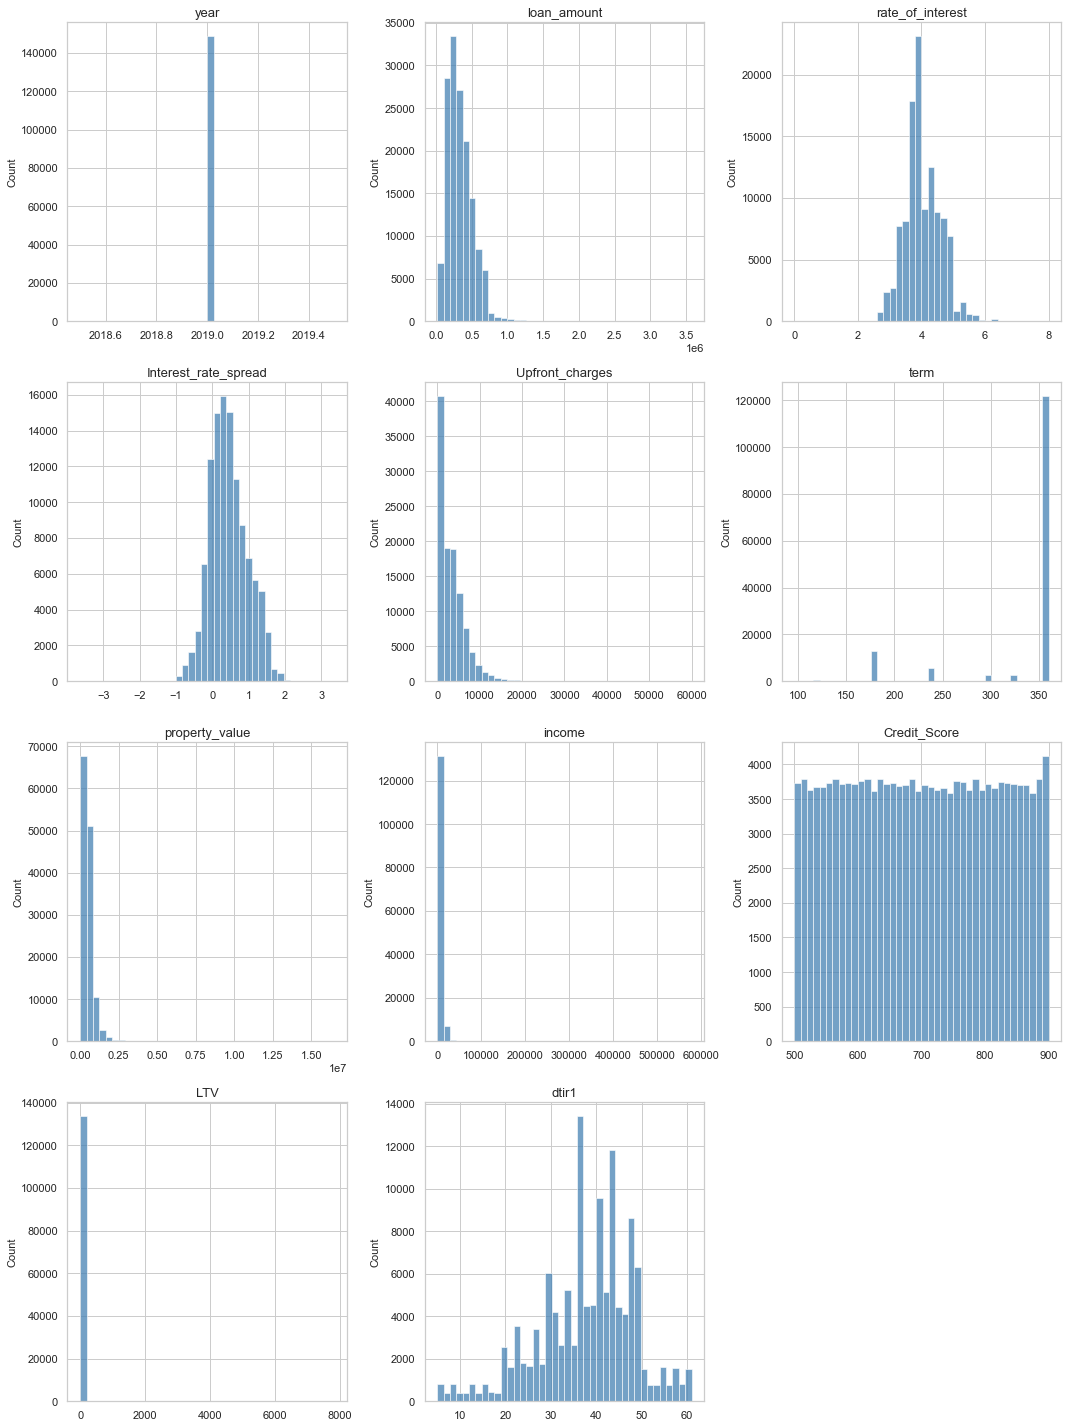

In [15]:
#Numerical features — histograms + KDE
cols = 3
n = len(num_feats)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()
for i, col in enumerate(num_feats):

    data = np.asarray(df[col].dropna(), dtype=float)

    sns.histplot(
        data,
        bins=40,
        ax=axes[i],
        color='steelblue'
    )

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

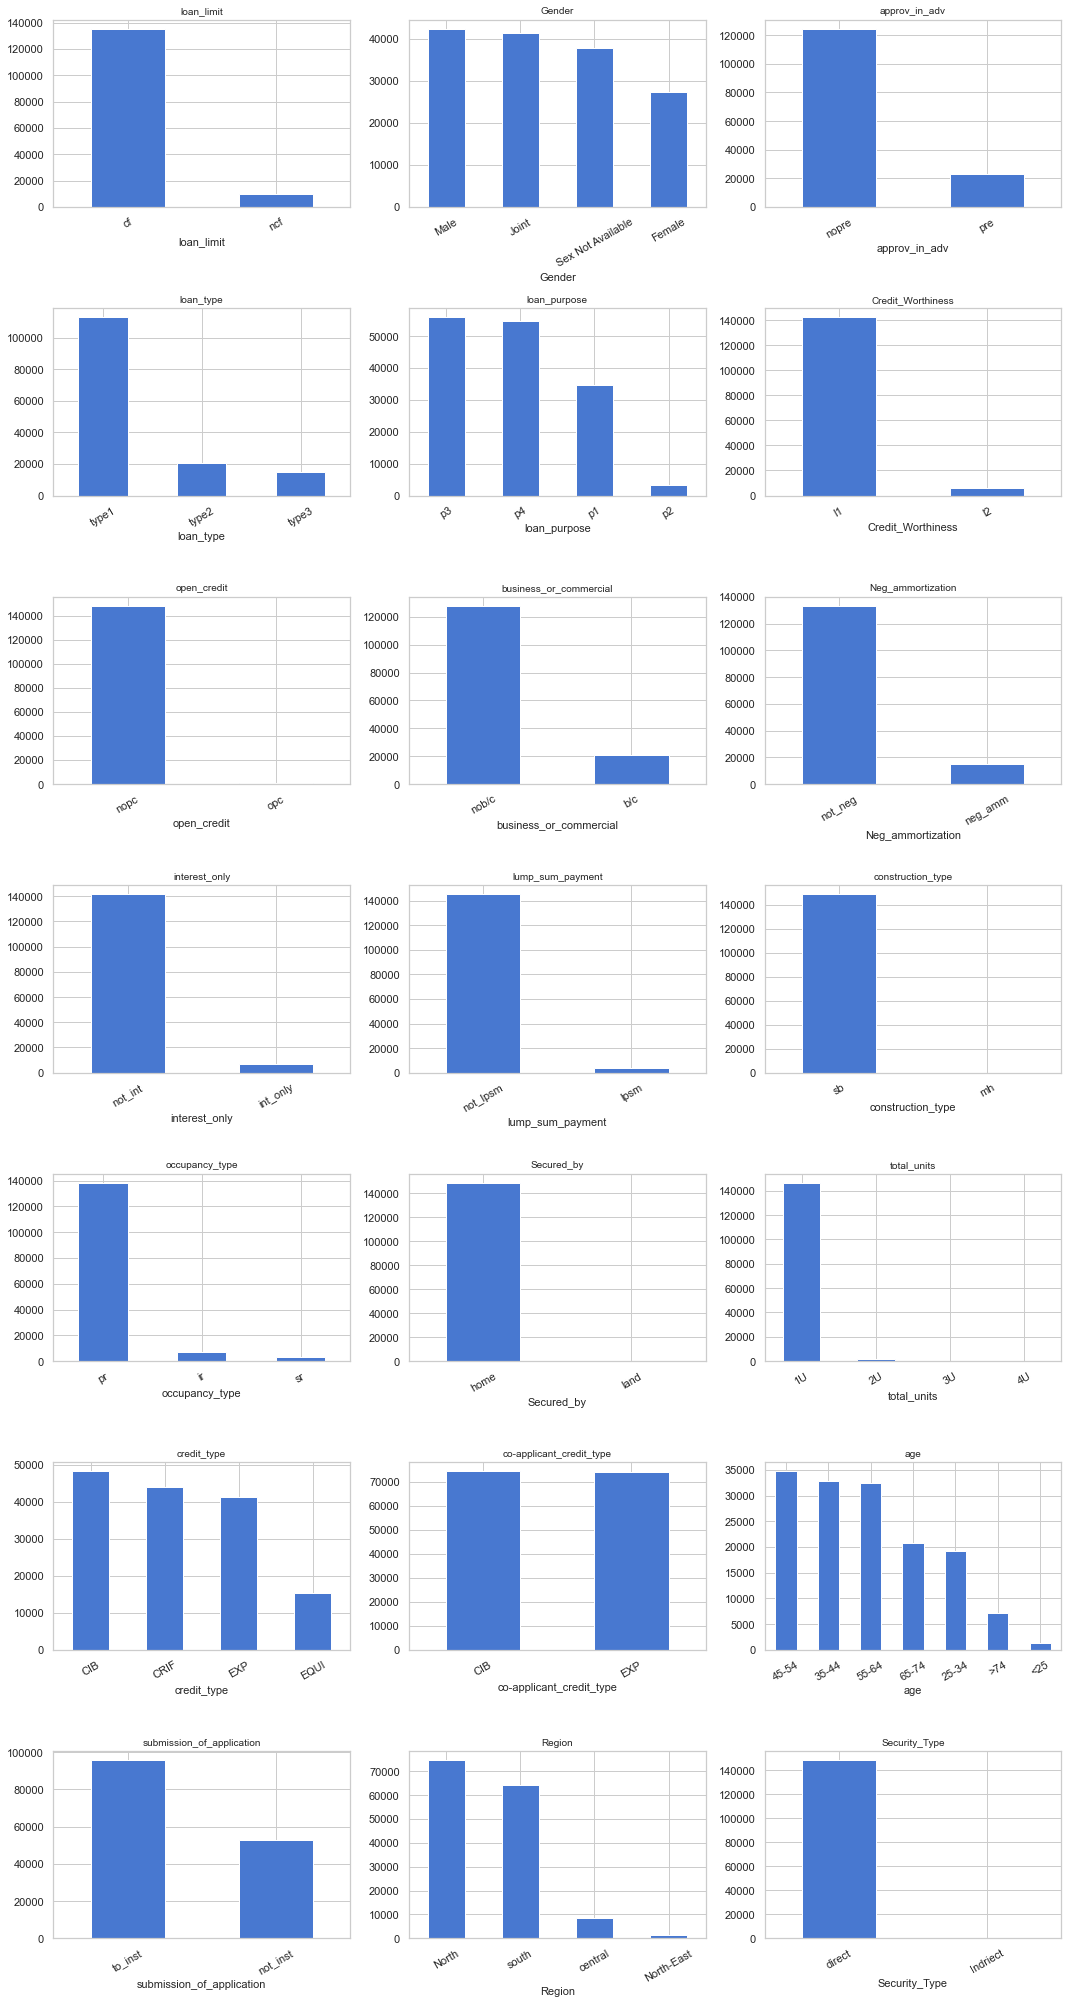

In [16]:
#Numerical features — histograms + KDE
n = len(cat_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row,
                             figsize=(15, 4 * rows))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(
            kind='bar',
            ax=axes[i]
        )

    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)
# Hide empty plots
for j in range(i + 1, len(axes)):
     axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Step 5 — Bivariate Analysis (Features vs Default Status)

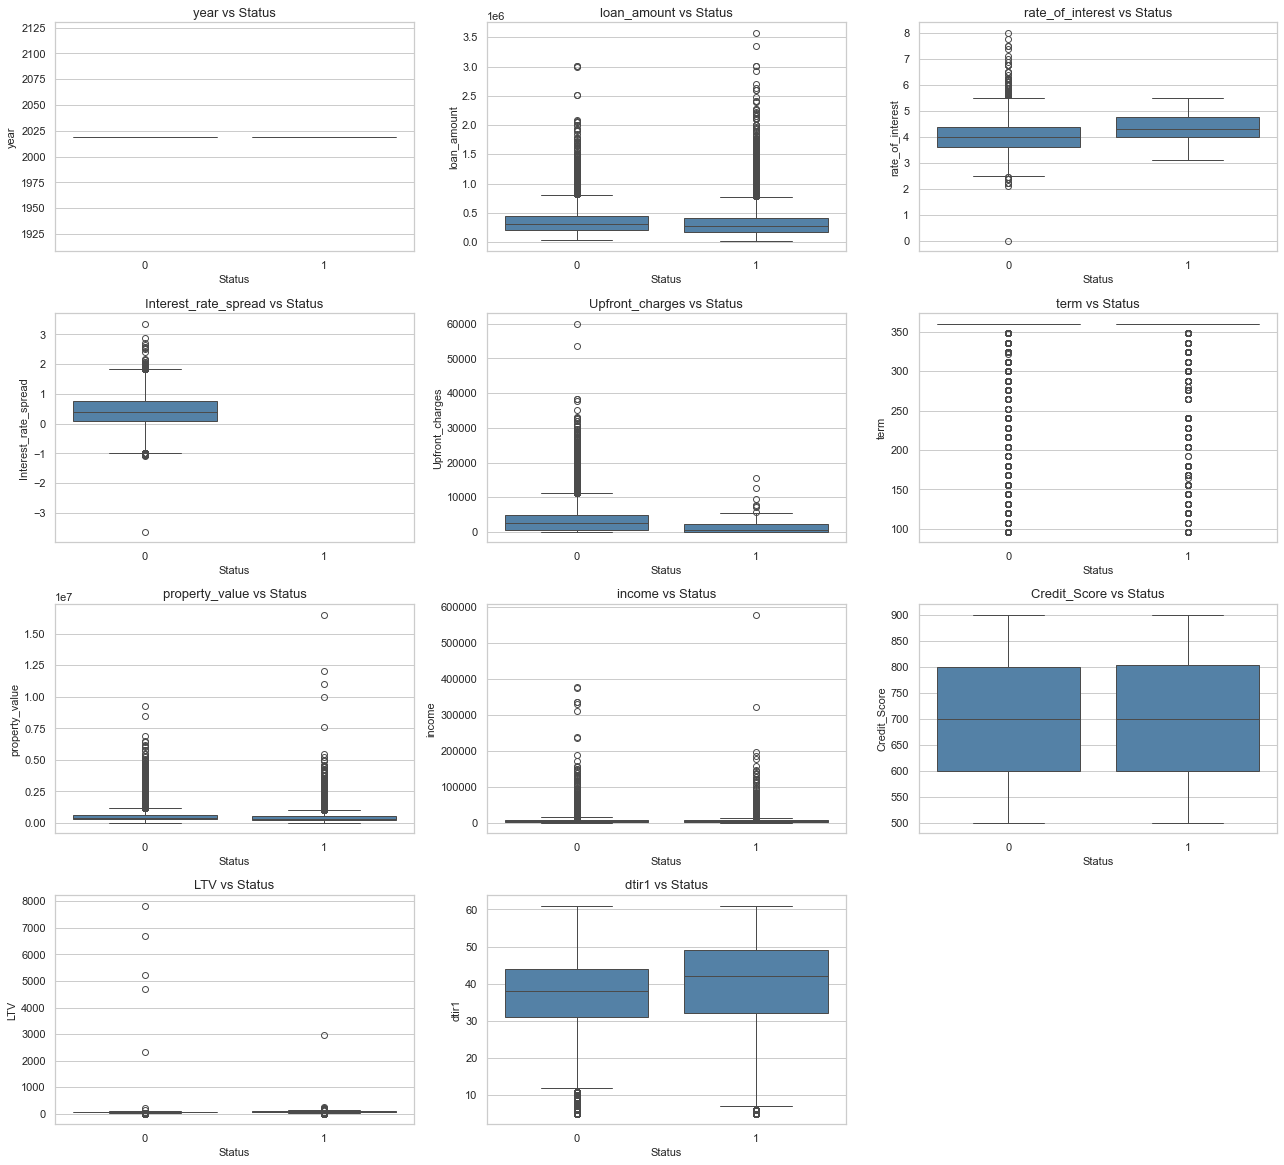

In [17]:
fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.boxplot(
        data=df,
        x=target,
        y=col,
        color='steelblue',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Status')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

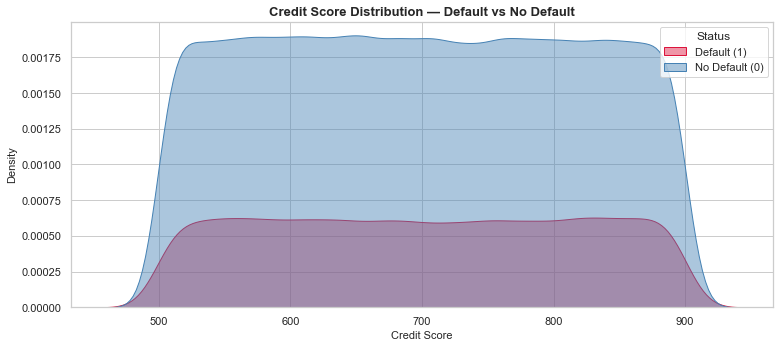

In [18]:
plt.figure(figsize=(11, 5))
sns.kdeplot(data=df, x='Credit_Score', hue=target, fill=True,
            palette={0: 'steelblue', 1: 'crimson'}, alpha=0.45)
plt.title('Credit Score Distribution — Default vs No Default', fontweight='bold')
plt.xlabel('Credit Score')
plt.legend(title='Status', labels=['Default (1)', 'No Default (0)'])
plt.tight_layout()
plt.show()

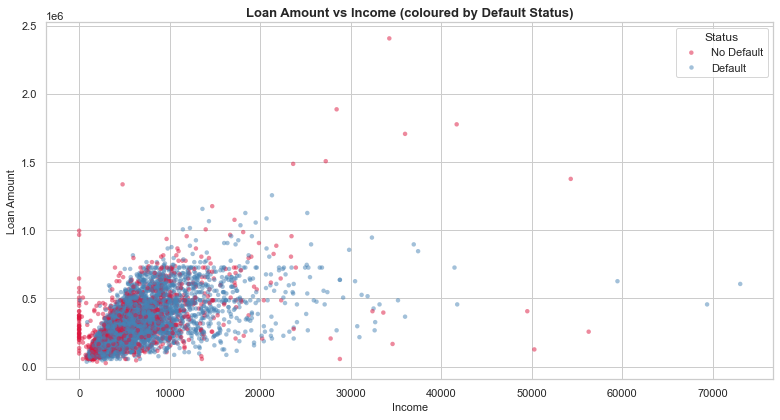

In [19]:
##Loan Amount vs Income — coloured by default status
sample = df[['loan_amount', 'income', target]].dropna().sample(5000, random_state=42)
plt.figure(figsize=(11, 6))
sns.scatterplot(data=sample, x='income', y='loan_amount',
                hue=target, palette={0: 'steelblue', 1: 'crimson'},
                alpha=0.5, edgecolor='none', s=20)
plt.title('Loan Amount vs Income (coloured by Default Status)', fontweight='bold')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.legend(title='Status', labels=['No Default', 'Default'])
plt.tight_layout()
plt.show()

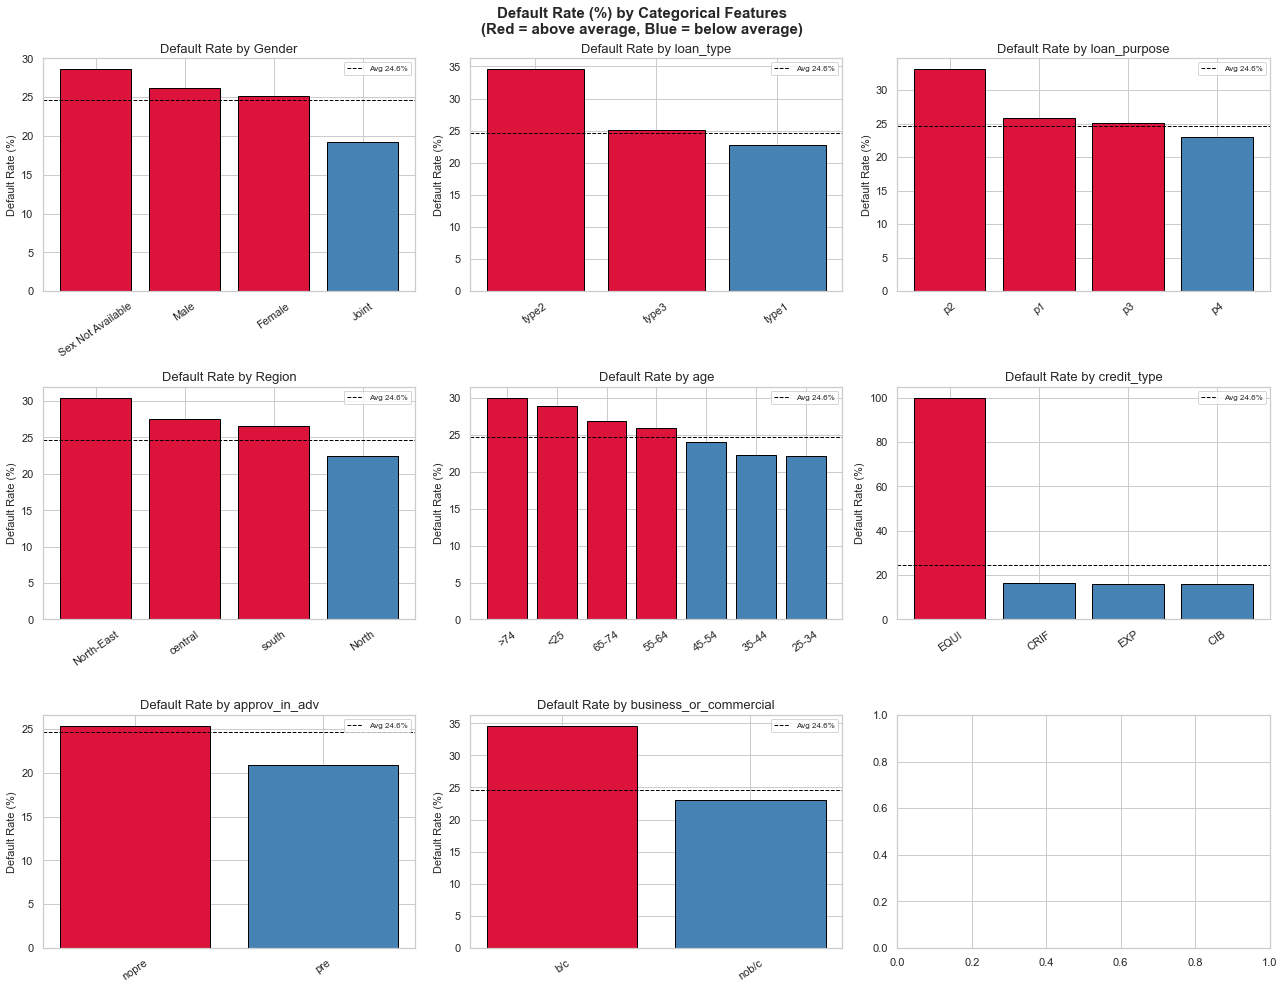

In [20]:
##Default rate by categorical features
key_cats = ['Gender', 'loan_type', 'loan_purpose', 'Region',
            'age', 'credit_type', 'approv_in_adv', 'business_or_commercial']
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(key_cats):
    if col not in df.columns:
        continue
    default_rate = counts[1] / counts.sum() * 100
    rate = df.groupby(col)[target].mean().sort_values(ascending=False) * 100
    colors = ['crimson' if v > default_rate else 'steelblue' for v in rate.values]
    axes[i].bar(rate.index.astype(str), rate.values, color=colors, edgecolor='black')
    axes[i].axhline(default_rate, color='black', linestyle='--',
                    linewidth=1, label=f'Avg {default_rate:.1f}%')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(fontsize=8)
plt.suptitle('Default Rate (%) by Categorical Features\n(Red = above average, Blue = below average)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

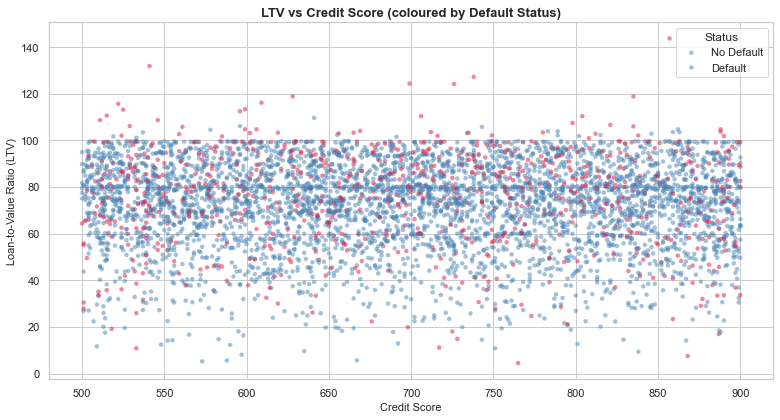

In [21]:
## LTV vs Credit Score — coloured by default
sample2 = df[['LTV', 'Credit_Score', target]].dropna().sample(5000, random_state=1)
plt.figure(figsize=(11, 6))
sns.scatterplot(data=sample2, x='Credit_Score', y='LTV',
                hue=target, palette={0: 'steelblue', 1: 'crimson'},
                alpha=0.5, edgecolor='none', s=20)
plt.title('LTV vs Credit Score (coloured by Default Status)', fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Loan-to-Value Ratio (LTV)')
plt.legend(title='Status', labels=['No Default', 'Default'])
plt.tight_layout()
plt.show()

## Step 6 — Correlation Analysis

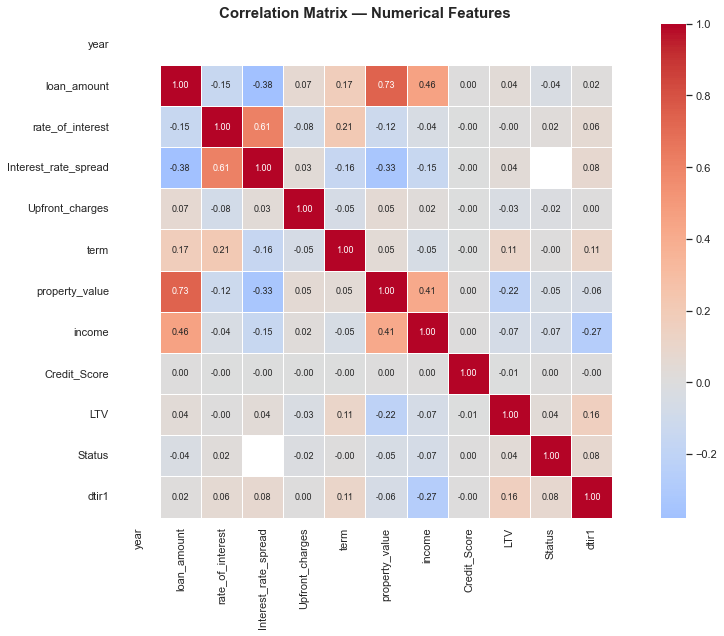

In [22]:
## Correlation heatmap (numerical columns)
corr = df[num_cols].corr()
plt.figure(figsize=(14, 9))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True, annot_kws={'size': 9})
plt.title('Correlation Matrix — Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

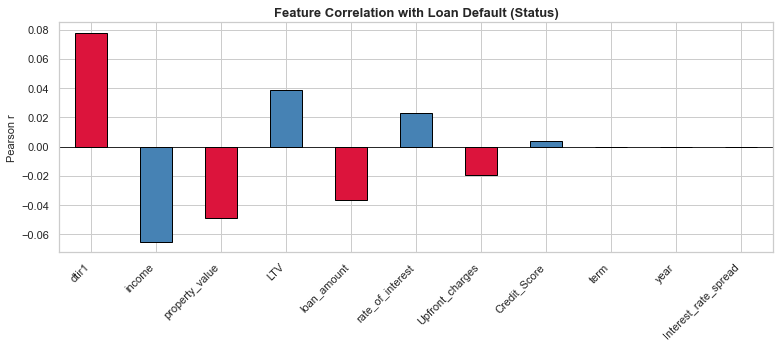


Correlation with Status (sorted by |r|):
dtir1                   0.078083
income                 -0.065119
property_value         -0.048864
LTV                     0.038895
loan_amount            -0.036825
rate_of_interest        0.022957
Upfront_charges        -0.019138
Credit_Score            0.004004
term                   -0.000240
year                         NaN
Interest_rate_spread         NaN


In [23]:
## Feature correlations with Status
target_corr = (corr[target]
               .drop(target)
               .sort_values(key=abs, ascending=False))
target_corr.plot(kind='bar', color=colors, edgecolor='black', figsize=(11, 5))
plt.title('Feature Correlation with Loan Default (Status)', fontweight='bold')
plt.ylabel('Pearson r')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('\nCorrelation with Status (sorted by |r|):')
print(target_corr.to_string())

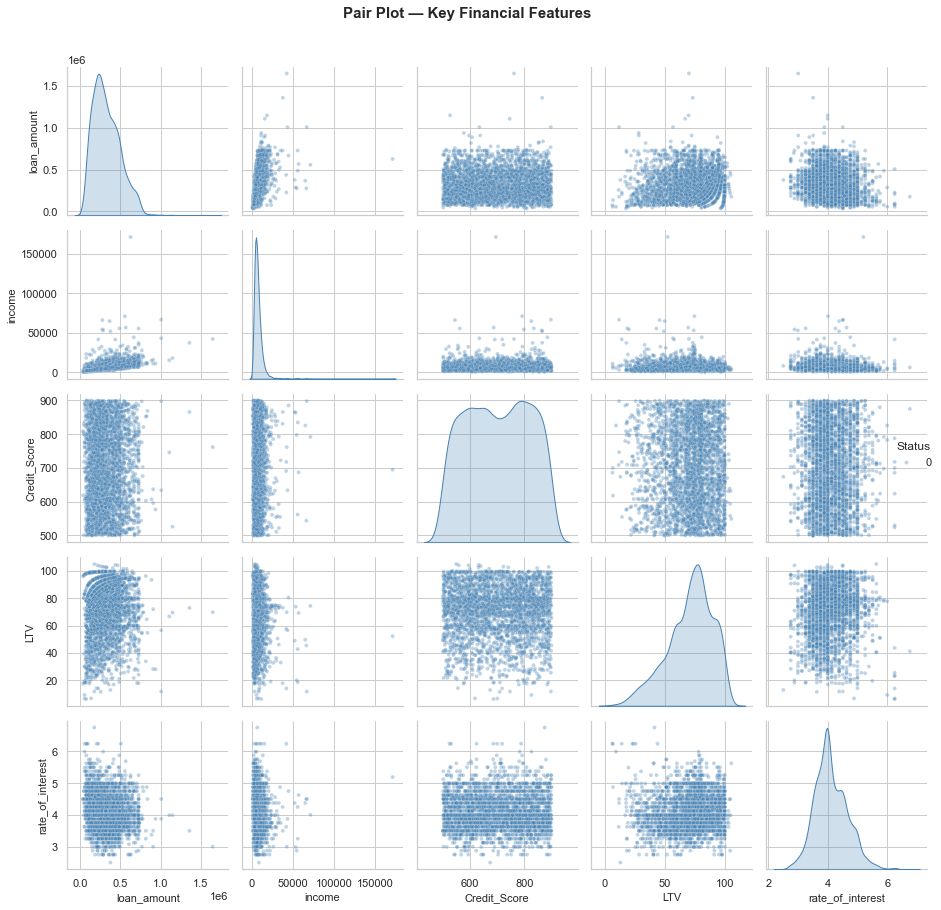

In [24]:
# 6.3  Pair plot — key financial features
pair_cols = ['loan_amount', 'income', 'Credit_Score', 'LTV',
             'rate_of_interest', target]
pair_df = df[pair_cols].dropna().sample(3000, random_state=42)
sns.pairplot(pair_df, hue=target,
             palette={0: 'steelblue', 1: 'crimson'},
             diag_kind='kde', plot_kws={'alpha': 0.35, 's': 15})
plt.suptitle('Pair Plot — Key Financial Features', y=1.01,
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

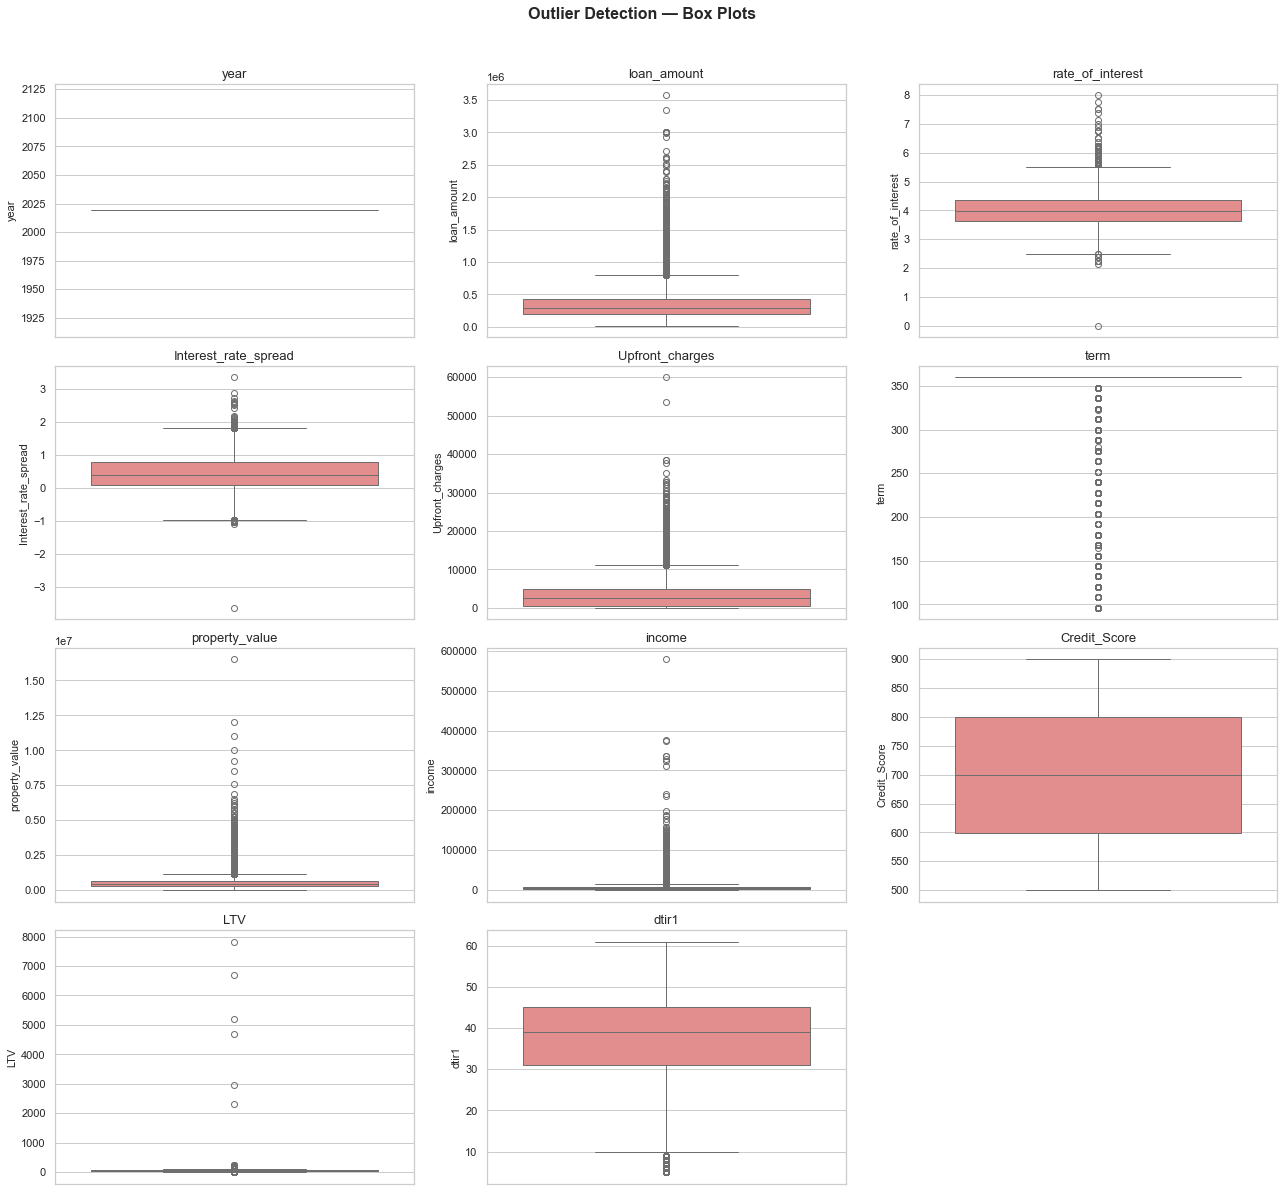

In [25]:
##Box plots for outlier visualisation
fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_feats):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Outlier Detection — Box Plots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [26]:
## IQR-based outlier count table
records = []
for col in num_feats:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
    records.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'Lower Fence': round(Q1 - 1.5*IQR, 2),
        'Upper Fence': round(Q3 + 1.5*IQR, 2),
        'Outlier Count': n_out,
        'Outlier %': round(n_out / len(df) * 100, 2)
    })
outlier_df = pd.DataFrame(records).set_index('Feature')
outlier_df

,Q1,Q3,Lower Fence,Upper Fence,Outlier Count,Outlier %
Feature,,,,,,
year,2019.00,2019.00,2019.00,2019.00,0,0.00
loan_amount,196500.00,436500.00,-163500.00,796500.00,1895,1.27
rate_of_interest,3.62,4.38,2.50,5.50,856,0.58
Interest_rate_spread,0.08,0.78,-0.97,1.82,445,0.30
Upfront_charges,581.49,4812.50,-5765.02,11159.02,2880,1.94
term,360.00,360.00,360.00,360.00,26944,18.12
property_value,268000.00,628000.00,-272000.00,1168000.00,5266,3.54
income,3720.00,8520.00,-3480.00,15720.00,6546,4.40
Credit_Score,599.00,800.00,297.50,1101.50,0,0.00


## Step 8 — Key Insights Summary

In [27]:
total    = len(df)
defaults = df[target].sum()
print(f'Dataset size: {total:,} rows x {df.shape[1]} columns' )
print(f'Defaulted loans: {defaults:,}')
print(f'Performing loans: {total-defaults:,}')
print('\nMissing data hotspots (>10%):')
high_miss = missing_df[missing_df['Missing%'] > 10]
print(high_miss)
print('\nTop numeric correlation with default')
print(target_corr.head())
print('\nMean feature values — Default vs No Default:')
print(df.groupby(target)[num_feats].mean().T.rename(columns={0: 'No Default', 1: 'Default'}))

Dataset size: 148,670 rows x 33 columns
Defaulted loans: 36,639
Performing loans: 112,031

Missing data hotspots (>10%):
                      Missing Count  Missing%
Upfront_charges               39642     26.66
Interest_rate_spread          36639     24.64
rate_of_interest              36439     24.51
dtir1                         24121     16.22
LTV                           15098     10.16
property_value                15098     10.16

Top numeric correlation with default
dtir1             0.078083
income           -0.065119
property_value   -0.048864
LTV               0.038895
loan_amount      -0.036825
Name: Status, dtype: float64

Mean feature values — Default vs No Default:
Status                   No Default        Default
year                    2019.000000    2019.000000
loan_amount           334990.774875  319275.184912
rate_of_interest           4.044931       4.350500
Interest_rate_spread       0.441656            NaN
Upfront_charges         3227.328554    1565.237974
ter

In [28]:
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

loan_limit                    3344
approv_in_adv                  908
loan_purpose                   134
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
property_value               15098
income                        9150
age                            200
submission_of_application      200
LTV                          15098
dtir1                        24121
dtype: int64


In [29]:
# Diagnostic: are pricing-related fields missing in a pattern that depends on
# the target? (Run on the untouched raw df — nothing fit here, no leakage risk.)
leak_cols = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'credit_type']
for c in leak_cols:
    print(c, df.groupby('Status')[c].apply(lambda x: x.isnull().sum()).to_dict())


rate_of_interest {0: 0, 1: 36439}
Interest_rate_spread {0: 0, 1: 36639}
Upfront_charges {0: 3156, 1: 36486}
credit_type {0: 0, 1: 0}


Interpretation: rate_of_interest, Interest_rate_spread, and Upfront_charges are missing almost exclusively for defaults and moreover pricing fields set after underwriting, so a live application model would never have them. credit_type is dropped separately because one category (EQUI) is a near-perfect proxy for default (~99.99%), which looks like a dataset artifact rather than a genuine credit signal. Both are structural, deterministic decisions — safe to apply before the split.

In [30]:
for c in ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Structural drop: leakage columns + useless columns (deterministic, safe pre-split)
df = df.drop(columns=['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
                       'credit_type', 'year', 'ID'], errors='ignore')
print('Shape after dropping leakage/useless columns:', df.shape)

Shape after dropping leakage/useless columns: (148670, 28)


##### Pipeline: 
**Split → Feature Engineering → Imputation → Encoding → Scaling → Model**


In [31]:
#Train_test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train default rate: {y_train.mean():.4f} | Test default rate: {y_test.mean():.4f}')


Train: (118936, 27), Test: (29734, 27)
Train default rate: 0.2464 | Test default rate: 0.2465


In [32]:
#Feature Engineering 
import numpy as np

def engineer(d):
    d = d.copy()
    # Deterministic cross-column derivation (pure algebra, row-wise — no leakage)
    mask_pv = d['property_value'].isnull() & d['LTV'].notnull()
    d.loc[mask_pv, 'property_value'] = d.loc[mask_pv, 'loan_amount'] / d.loc[mask_pv, 'LTV'] * 100
    mask_ltv = d['LTV'].isnull() & d['property_value'].notnull()
    d.loc[mask_ltv, 'LTV'] = d.loc[mask_ltv, 'loan_amount'] / d.loc[mask_ltv, 'property_value'] * 100

    # NaN-safe flags: a missing input produces a missing flag, not a silent 0/False
    d['high_dti'] = np.where(d['dtir1'].isna(), np.nan, (d['dtir1'] > 40).astype(float))
    d['high_ltv_flag'] = np.where(d['LTV'].isna(), np.nan, (d['LTV'] > 80).astype(float))
    d['loan_to_income'] = d['loan_amount'] / (d['income'] + 1)   # NaN propagates naturally
    d['term_years'] = d['term'] / 12                              # NaN propagates naturally
    d['credit_score_band'] = pd.cut(                              # Credit_Score has no missing values
        d['Credit_Score'], bins=[0, 580, 670, 740, 800, float('inf')],
        labels=['Very Poor', 'Fair', 'Good', 'Very Good', 'Exceptional'], include_lowest=True
    )
    return d

X_train = engineer(X_train)
X_test = engineer(X_test)
print('Shape after feature engineering — train:', X_train.shape, '| test:', X_test.shape)
print('\nMissing values introduced/remaining (train):')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])


Shape after feature engineering — train: (118936, 32) | test: (29734, 32)

Missing values introduced/remaining (train):
loan_limit                    2696
approv_in_adv                  715
loan_purpose                   103
term                            33
Neg_ammortization               96
property_value               12001
income                        7355
age                            156
submission_of_application      156
LTV                          12001
dtir1                        19254
high_dti                     19254
high_ltv_flag                12001
loan_to_income                7355
term_years                      33
dtype: int64


In [33]:
#Imputation for missing variables
from sklearn.impute import SimpleImputer

median_cols = ['dtir1', 'income', 'property_value', 'LTV', 'term', 'loan_to_income', 'term_years']
mode_num_cols = ['high_dti', 'high_ltv_flag']  # binary flags -> most_frequent
mode_cat_cols = ['loan_limit', 'approv_in_adv', 'loan_purpose', 'Neg_ammortization',
                 'age', 'submission_of_application']

median_imputer = SimpleImputer(strategy='median').fit(X_train[median_cols])
X_train[median_cols] = median_imputer.transform(X_train[median_cols])
X_test[median_cols] = median_imputer.transform(X_test[median_cols])

mode_num_imputer = SimpleImputer(strategy='most_frequent').fit(X_train[mode_num_cols])
X_train[mode_num_cols] = mode_num_imputer.transform(X_train[mode_num_cols])
X_test[mode_num_cols] = mode_num_imputer.transform(X_test[mode_num_cols])

mode_cat_imputer = SimpleImputer(strategy='most_frequent').fit(X_train[mode_cat_cols])
X_train[mode_cat_cols] = mode_cat_imputer.transform(X_train[mode_cat_cols])
X_test[mode_cat_cols] = mode_cat_imputer.transform(X_test[mode_cat_cols])

assert X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0
print('No missing values remain in either split.')


No missing values remain in either split.


In [34]:
#Encoding (Binary and One hot)
from sklearn.preprocessing import OneHotEncoder

binary_map = {
    'loan_limit'               : {'cf': 0, 'ncf': 1},
    'approv_in_adv'            : {'nopre': 0, 'pre': 1},
    'Credit_Worthiness'        : {'l1': 0, 'l2': 1},
    'open_credit'              : {'nopc': 0, 'opc': 1},
    'business_or_commercial'   : {'nob/c': 0, 'b/c': 1},
    'Neg_ammortization'        : {'not_neg': 0, 'neg_amm': 1},
    'interest_only'            : {'not_int': 0, 'int_only': 1},
    'lump_sum_payment'         : {'not_lpsm': 0, 'lpsm': 1},
    'construction_type'        : {'sb': 0, 'mh': 1},
    'Secured_by'               : {'home': 0, 'land': 1},
    'co-applicant_credit_type' : {'CIB': 0, 'EXP': 1},
    'submission_of_application': {'to_inst': 0, 'not_inst': 1},
    'Security_Type'            : {'direct': 0, 'Indriect': 1},  # note: typo in raw data
}
for col, mapping in binary_map.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

ohe_cols = ['Gender', 'loan_type', 'loan_purpose', 'occupancy_type',
            'total_units', 'Region', 'age', 'credit_score_band']
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[ohe_cols])

train_ohe = pd.DataFrame(ohe.transform(X_train[ohe_cols]),
                          columns=ohe.get_feature_names_out(ohe_cols), index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[ohe_cols]),
                         columns=ohe.get_feature_names_out(ohe_cols), index=X_test.index)
X_train = pd.concat([X_train.drop(columns=ohe_cols), train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=ohe_cols), test_ohe], axis=1)

def clean_cols(cols):
    return [str(c).replace('[', '(').replace(']', ')').replace('<', 'lt')
                  .replace(',', '_').replace(' ', '_') for c in cols]
X_train.columns = clean_cols(X_train.columns)
X_test.columns = clean_cols(X_test.columns)

assert list(X_train.columns) == list(X_test.columns)
print('Final modeling shape — train:', X_train.shape, '| test:', X_test.shape)
print('Nulls remaining:', X_train.isnull().sum().sum() + X_test.isnull().sum().sum())


Final modeling shape — train: (118936, 50) | test: (29734, 50)
Nulls remaining: 0


In [35]:
#Scaling for logistic regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print('Scaled shapes:', X_train_sc.shape, X_test_sc.shape)


Scaled shapes: (118936, 50) (29734, 50)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
models = {}
# Logistic Regression — interpretable baseline (scorecard-style)
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, random_state=42)
logreg.fit(X_train_sc, y_train)
models['Logistic Regression'] = logreg
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                             class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               scale_pos_weight=scale_pos_weight,
                               eval_metric='auc', random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)
models['LightGBM'] = lgb_model
print("All models trained:", list(models.keys()))

All models trained: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


In [37]:
import numpy as np
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score, precision_score,
                              recall_score, f1_score, brier_score_loss)
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(np.abs(tpr - fpr))
rows, roc_data = [], {}
for name, m in models.items():
    Xte = X_test_sc if name == 'Logistic Regression' else X_test
    prob = m.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)
    auc = roc_auc_score(y_test, prob)
    rows.append({'Model': name, 'AUC': auc, 'Gini': 2*auc-1, 'KS': ks_statistic(y_test, prob),
                 'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred),
                 'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred),
                 'Brier': brier_score_loss(y_test, prob)})
    roc_data[name] = roc_curve(y_test, prob)[:2] + (auc,)

results_df = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,AUC,Gini,KS,Accuracy,Precision,Recall,F1,Brier
0,LightGBM,0.8994,0.7987,0.6646,0.8810,0.7714,0.7351,0.7528,0.1015
1,XGBoost,0.8985,0.7969,0.6606,0.8790,0.7656,0.7339,0.7494,0.1024
2,Random Forest,0.8863,0.7727,0.6325,0.8755,0.7773,0.6938,0.7331,0.1168
3,Logistic Regression,0.7761,0.5523,0.4265,0.7266,0.4620,0.6661,0.5456,0.1858


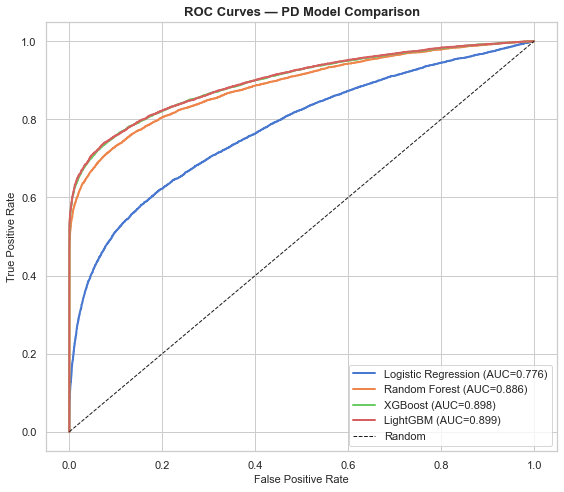

In [38]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — PD Model Comparison', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

##### Interpretation
1) Multiple classification models were evaluated using the same train-test split to ensure a fair comparison.

2) ROC-AUC was used as the primary evaluation metric because Probability of Default (PD) models require accurate ranking of borrowers by risk rather than simply maximizing classification accuracy.

3) The model with the highest ROC-AUC (LightBGM) was selected as the final PD model because it provides the best discrimination between defaulting and non-defaulting borrowers.

4) Although accuracy is reported, it can be misleading in credit risk datasets where defaults are often less frequent than non-defaults.

1) The ROC curve illustrates the trade-off between True Positive Rate and False Positive Rate across different classification thresholds.

2) A curve closer to the upper-left corner indicates stronger discriminatory power.

3) The selected model consistently achieved a higher ROC-AUC than the alternative models, indicating better ability to rank borrowers according to default risk.

4) This makes the model suitable for credit risk applications where borrower ranking is more important than fixed-threshold classification.

Best model: LightGBM

              precision    recall  f1-score   support

  No Default       0.91      0.93      0.92     22406
     Default       0.77      0.74      0.75      7328

    accuracy                           0.88     29734
   macro avg       0.84      0.83      0.84     29734
weighted avg       0.88      0.88      0.88     29734



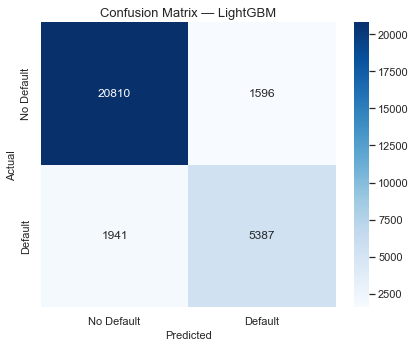

In [39]:
from sklearn.metrics import confusion_matrix, classification_report
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
Xte_best = X_test_sc if best_name == 'Logistic Regression' else X_test
prob_best = best_model.predict_proba(Xte_best)[:, 1]
pred_best = (prob_best >= 0.5).astype(int)
print(f"Best model: {best_name}\n")
print(classification_report(y_test, pred_best, target_names=['No Default', 'Default']))
cm = confusion_matrix(y_test, pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title(f'Confusion Matrix — {best_name}'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

##### Interpretation
1) Precision measures the proportion of predicted defaults that were actually defaults.

2) Recall measures how many actual defaults were correctly identified.

3) F1-score balances precision and recall.

4) For PD modeling, recall is particularly important because failing to identify high-risk borrowers can result in significant financial losses.

5) The classification report indicates that the model maintains a reasonable balance between identifying risky borrowers while minimizing false alarms.

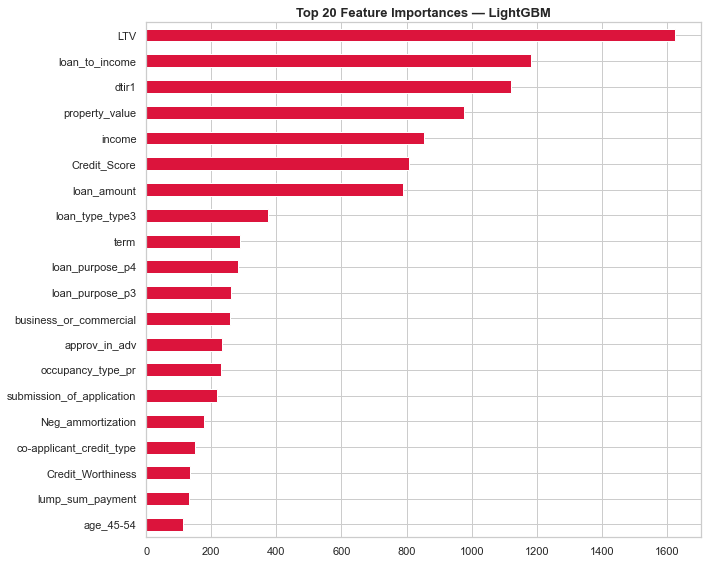

In [40]:
plt.figure(figsize=(10, 8))
if best_name == 'Logistic Regression':
    coefs = pd.Series(best_model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False).head(20)
    coefs.sort_values().plot(kind='barh', color='steelblue')
    plt.title('Top 20 Logistic Regression Coefficients (standardized)', fontweight='bold')
else:
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
    imp.sort_values().plot(kind='barh', color='crimson')
    plt.title(f'Top 20 Feature Importances — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

1) The most influential variables contribute the greatest predictive power to estimating borrower default probability.

2) Variables appearing at the top of the importance ranking have the strongest relationship with credit risk.

3) Understanding these drivers improves model interpretability and supports regulatory model documentation.

4) The importance rankings also help validate whether economically meaningful variables are influencing predictions.

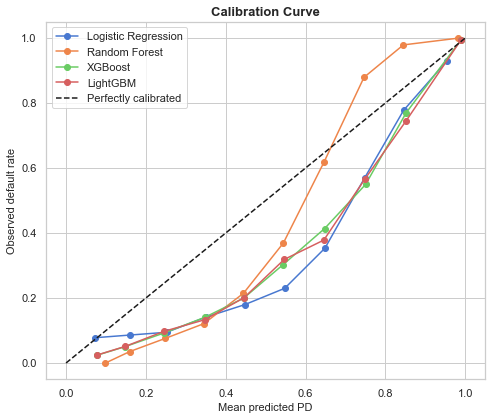

In [41]:
from sklearn.calibration import calibration_curve
plt.figure(figsize=(7, 6))
for name, m in models.items():
    Xte = X_test_sc if name == 'Logistic Regression' else X_test
    prob = m.predict_proba(Xte)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted PD'); plt.ylabel('Observed default rate')
plt.title('Calibration Curve', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

1) Calibration measures how closely predicted probabilities match observed default rates.

2) A perfectly calibrated model lies on the diagonal line.

3) Curves close to the diagonal indicate that predicted PD values can be interpreted as realistic probabilities.

4) Good calibration is essential for pricing loans, estimating expected credit losses, stress testing, and regulatory capital calculations.

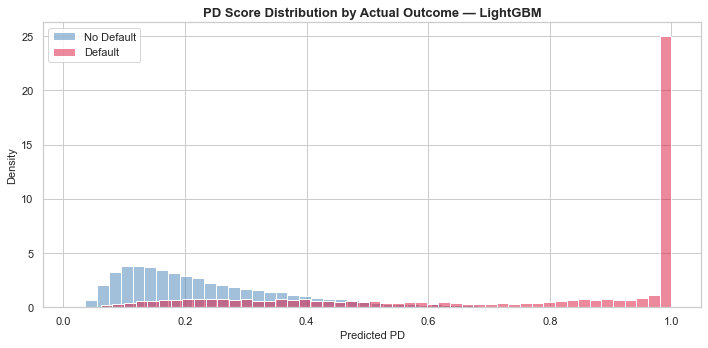

In [42]:
plt.figure(figsize=(10, 5))
sns.histplot(prob_best[y_test == 0], bins=50, color='steelblue', label='No Default', stat='density', alpha=0.5)
sns.histplot(prob_best[y_test == 1], bins=50, color='crimson', label='Default', stat='density', alpha=0.5)
plt.xlabel('Predicted PD')
plt.title(f'PD Score Distribution by Actual Outcome — {best_name}', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

1) Non-default borrowers are concentrated in lower predicted PD ranges.

2) Default borrowers generally receive higher predicted probabilities.

3) The separation between the two distributions demonstrates the model's ability to distinguish low-risk from high-risk borrowers.

4) Some overlap is expected because borrower characteristics are rarely perfectly separable.

In [43]:
# Risk bands
bands = pd.cut(prob_best, bins=[0, 0.1, 0.25, 0.5, 0.75, 1.0],
               labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
band_df = pd.DataFrame({'pd': prob_best, 'band': bands, 'actual': y_test.values})
band_summary = band_df.groupby('band').agg(
    n=('pd', 'size'), avg_pd=('pd', 'mean'), actual_default_rate=('actual', 'mean')
).round(4)
band_summary

,n,avg_pd,actual_default_rate
band,,,
Very Low,3199,0.0773,0.0244
Low,11457,0.1688,0.0607
Medium,8095,0.3509,0.1442
High,2070,0.6026,0.3618
Very High,4913,0.9607,0.9440


1) Borrowers were segmented into five probability-of-default bands.

2) The observed default rate increases consistently from Very Low to Very High risk.

3) This monotonic trend demonstrates that the PD estimates are meaningful and suitable for practical credit risk segmentation.

4) Such risk bands can support:

**Loan approval decisions**,**Risk-based pricing**,**Portfolio monitoring**,**Credit limit assignment**,**Expected loss estimation**